In [1]:
import torch
import torch.nn as nn

# Input (X) and Target (y)
# We want the model to learn that y = x^2
X = torch.tensor([[1.0], [2.0], [3.0], [4.0], [5.0], [6.0], [7.0]], dtype=torch.float32)
y = torch.tensor([[1.0], [4.0], [9.0], [16.0], [25.0], [36.0], [49.0]], dtype=torch.float32)

# A simple model with 1 input and 1 output
model = nn.Sequential(
    nn.Linear(1, 10),
    nn.LeakyReLU(),
    nn.Linear(10, 10),
    nn.LeakyReLU(),
    nn.Linear(10, 1)
)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)

In [2]:
for epoch in range(10_000):
    # 1. Forward pass: Compute predicted y by passing X to the model
    y_pred = model(X)

    # 2. Compute loss
    loss = criterion(y_pred, y)

    # 3. Zero gradients, perform a backward pass, and update weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 20 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

Epoch 20, Loss: 674.7509
Epoch 40, Loss: 666.5321
Epoch 60, Loss: 659.1745
Epoch 80, Loss: 648.5755
Epoch 100, Loss: 624.7599
Epoch 120, Loss: 559.4415
Epoch 140, Loss: 372.7961
Epoch 160, Loss: 106.3358
Epoch 180, Loss: 59.5940
Epoch 200, Loss: 58.0136
Epoch 220, Loss: 57.1516
Epoch 240, Loss: 56.3159
Epoch 260, Loss: 55.5003
Epoch 280, Loss: 54.7032
Epoch 300, Loss: 53.9233
Epoch 320, Loss: 53.1595
Epoch 340, Loss: 52.4107
Epoch 360, Loss: 51.6758
Epoch 380, Loss: 50.9539
Epoch 400, Loss: 50.2442
Epoch 420, Loss: 49.5460
Epoch 440, Loss: 48.8584
Epoch 460, Loss: 48.1809
Epoch 480, Loss: 47.5127
Epoch 500, Loss: 46.8535
Epoch 520, Loss: 46.2025
Epoch 540, Loss: 45.5593
Epoch 560, Loss: 44.9236
Epoch 580, Loss: 44.2948
Epoch 600, Loss: 43.6725
Epoch 620, Loss: 43.0565
Epoch 640, Loss: 42.4463
Epoch 660, Loss: 41.8417
Epoch 680, Loss: 41.2424
Epoch 700, Loss: 40.6482
Epoch 720, Loss: 40.0640
Epoch 740, Loss: 39.4848
Epoch 760, Loss: 38.9104
Epoch 780, Loss: 38.3407
Epoch 800, Loss: 37.7

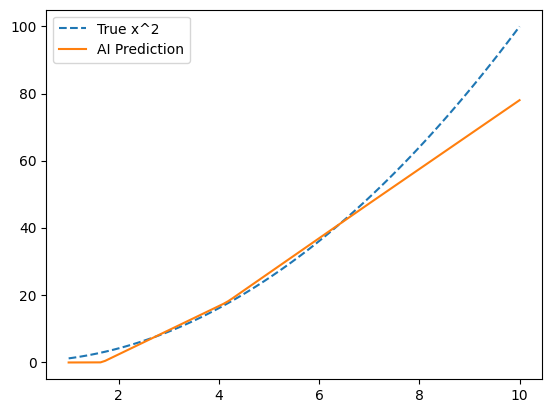

In [3]:
import matplotlib.pyplot as plt

# Generate range of x from 1 to 10
x_test = torch.linspace(1, 10, 100).reshape(-1, 1)
with torch.no_grad():
    y_pred = model(x_test)

plt.plot(x_test, x_test**2, label='True x^2', linestyle='--')
plt.plot(x_test, y_pred, label='AI Prediction')
plt.legend()
plt.show()